<a href="https://colab.research.google.com/github/annaselma/shisho-trading-assistant/blob/develop/Crypto_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# import libraries
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
from pandas.plotting import autocorrelation_plot
from google.colab import drive

drive.mount('/content/drive')
# Load data
df = pd.read_csv('/content/drive/MyDrive/Bitcoin History.csv')
df.head()



Mounted at /content/drive


,Date,Price,Open,High,Low,Vol.,Change %
0,"Feb 09, 2024","47,545.4","45,293.3","47,710.2","45,254.2",86.85K,4.97%
1,"Feb 08, 2024","45,293.3","44,346.2","45,579.2","44,336.4",66.38K,2.15%
2,"Feb 07, 2024","44,339.8","43,088.4","44,367.9","42,783.5",48.57K,2.91%
3,"Feb 06, 2024","43,087.7","42,697.6","43,375.5","42,566.8",33.32K,0.91%
4,"Feb 05, 2024","42,697.2","42,581.4","43,532.2","42,272.5",39.26K,0.27%


In [27]:
print(df.shape)

(4955, 7)


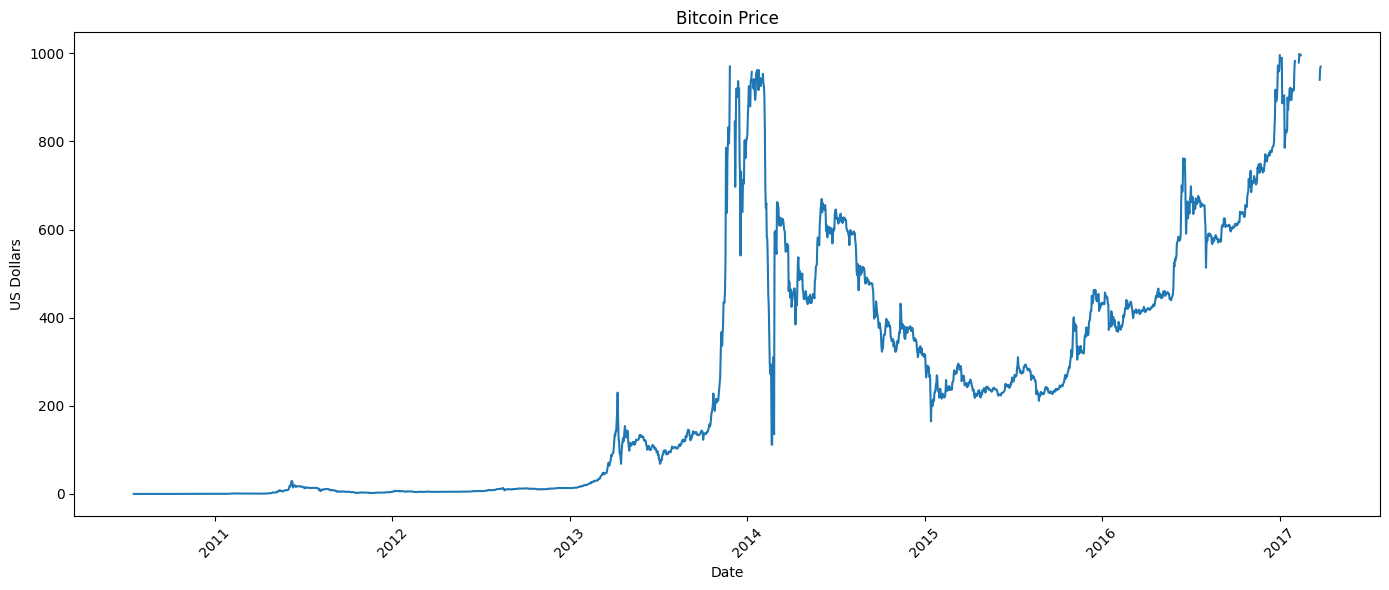

In [28]:
# graph bitcoin price over the years
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'])

# Format the 'Date' column to 'day-month-year'
df['Formatted_Date'] = df['Date'].dt.strftime('%d-%m-%Y')
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Price'])
plt.title('Bitcoin Price')
plt.xlabel('Date')
plt.ylabel('US Dollars')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()

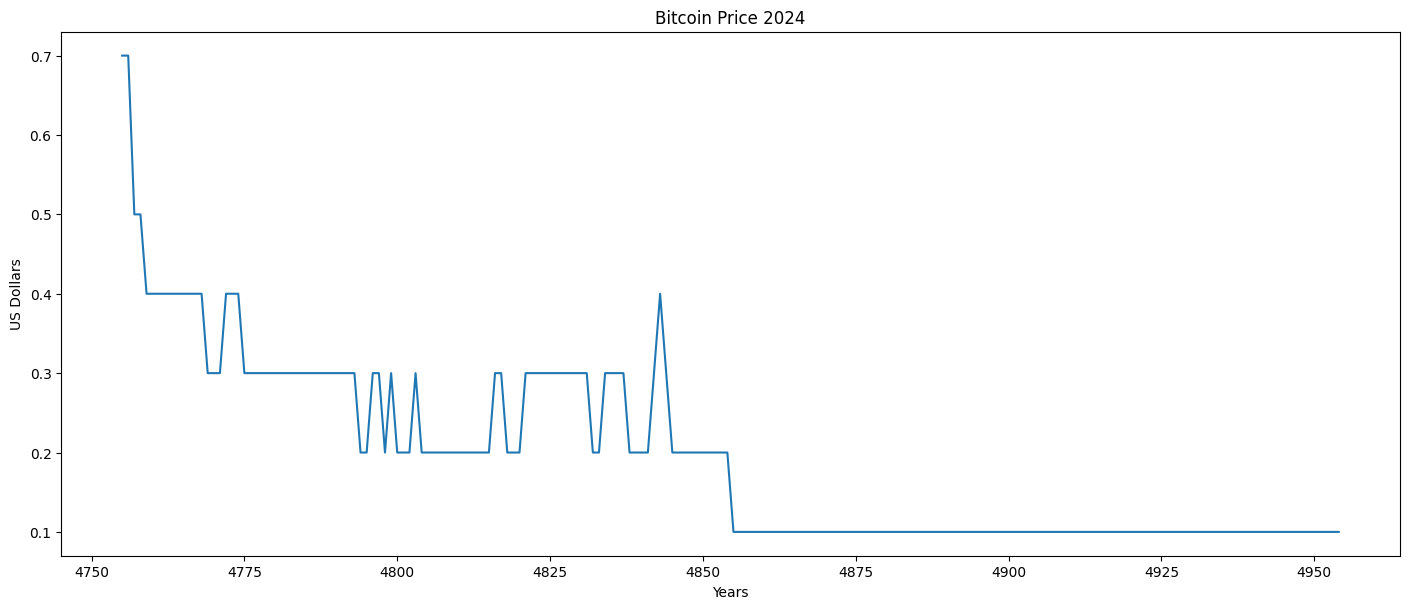

In [32]:
# let's look at the past 200 days to possibly adjust our data to this period
df.Price.iloc[-200:].plot(title = "Bitcoin Price 2024", figsize=(14,6))
plt.tight_layout()
plt.xlabel('Years')
plt.ylabel('US Dollars')
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this

Mean Squared Error: 2.261505940865974


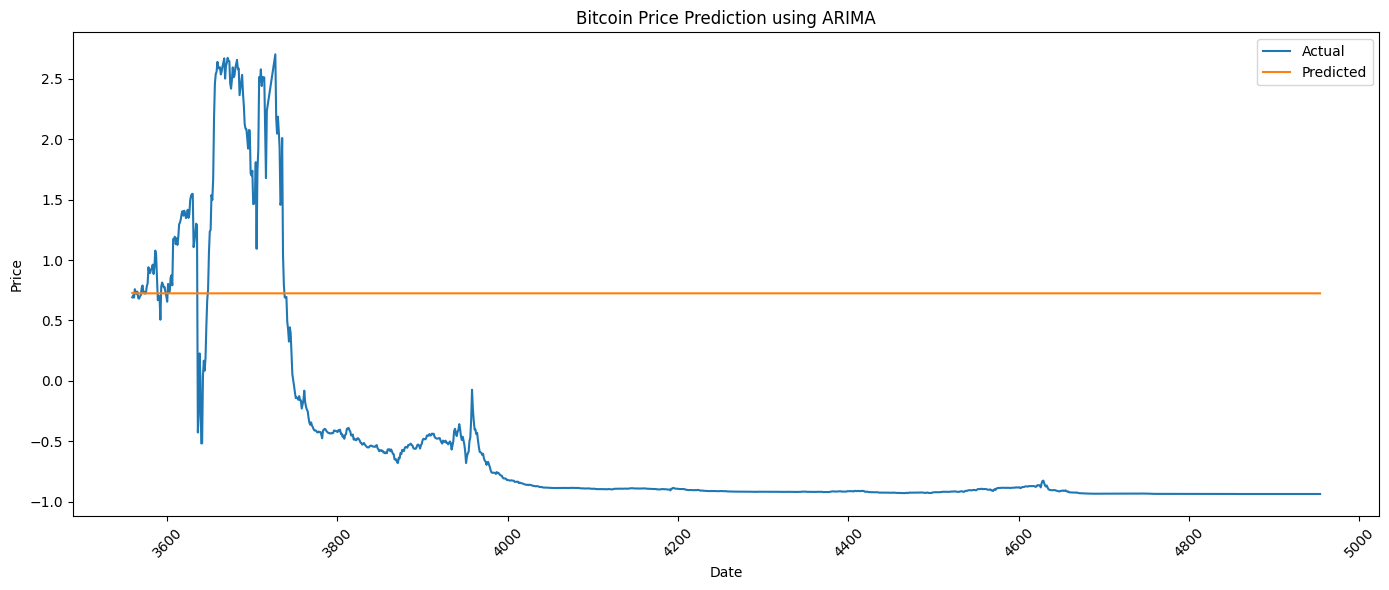

In [40]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Use 'Price' as the target variable 'Price'
df['Price'] = df['Price']

# Drop any rows with missing values
df.dropna(subset=['Price'], inplace=True)

# Normalize the Price data
scaler = StandardScaler()
df['Price'] = scaler.fit_transform(df[['Price']])

# Step 4: Train-Test Split
# Split the data into training and testing sets
train_data = df.iloc[:1000]  # Adjust the number of training samples as needed
test_data = df.iloc[1000:]

# Step 5: Build ARIMA Model
# Fit an ARIMA model to the training data
arima_model = ARIMA(train_data['Price'], order=(5,1,0))
fitted_model = arima_model.fit()

# Step 6: Make Predictions
# Use the fitted model to make predictions on the test data
predictions = fitted_model.predict(start=len(train_data), end=len(train_data)+len(test_data)-1, typ='levels')

# Inverse transform the predictions
predictions = scaler.inverse_transform(predictions.values.reshape(-1, 1))

# Inverse transform the test data prices
test_data['Price'] = scaler.inverse_transform(test_data['Price'].values.reshape(-1, 1))

# Step 7: Evaluate Model
# Evaluate the performance of the ARIMA model
mse = mean_squared_error(test_data['Price'], predictions)
print("Mean Squared Error:", mse)

# Step 8: Visualize Results
# Visualize the actual vs. predicted Bitcoin prices
plt.figure(figsize=(14, 6))
plt.plot(test_data.index, test_data['Price'], label='Actual')
plt.plot(test_data.index, predictions, label='Predicted')
plt.legend()
plt.title('Bitcoin Price Prediction using ARIMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
from statsmodels.tsa.arima_model import ARIMA
# We're going to create a dataframe for just the price (the index is still the date)
price = df.Price
# Next we're going to assign 70% percent of the data to training and 30% for testing
X = price.values
size = int(len(X) * 0.7)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(5,1,0))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

NotImplementedError: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been removed in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and statsmodels.tsa.SARIMAX.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained. It also offers alternative specialized
parameter estimators.
